# Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis for the resume-job matching project.

The goal of this EDA is not only to inspect the dataset, but also to motivate the downstream feature engineering choices, including:

- Bag-of-Words and TF-IDF text representations
- resume-job overlap ratio
- cosine similarity between resumes and job descriptions
- technical skill matching features

In [344]:
import pandas as pd 
import seaborn as sns 
from tabulate import tabulate
import matplotlib.pyplot as plt
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
import string
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/shiyili/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/shiyili/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 1. Load Dataset

In [345]:
# load the Resume_Screening_Dataset from a local CSV file.
df = pd.read_csv('../data/Resume_Screening_Dataset.csv', dtype={"Resume": str, "Job_Description": str, "Decision": str})
# display the first few rows of the dataset
print("First few rows of the dataset:")
# print(tabulate(df.head(), headers='keys', tablefmt='grid'))
display(df.head())


First few rows of the dataset:


,Role,Resume,Decision,Reason_for_decision,Job_Description
0,E-commerce Specialist,Here's a professional resume for Jason Jones:\...,reject,Lacked leadership skills for a senior position.,Be part of a passionate team at the forefront ...
1,Game Developer,Here's a professional resume for Ann Marshall:...,select,Strong technical skills in AI and ML.,Help us build the next-generation products as ...
2,Human Resources Specialist,Here's a professional resume for Patrick Mccla...,reject,Insufficient system design expertise for senio...,We need a Human Resources Specialist to enhanc...
3,E-commerce Specialist,Here's a professional resume for Patricia Gray...,select,Impressive leadership and communication abilit...,Be part of a passionate team at the forefront ...
4,E-commerce Specialist,Here's a professional resume for Amanda Gross:...,reject,Lacked leadership skills for a senior position.,We are looking for an experienced E-commerce S...


Output interpretation: The first five rows show that the dataset contains resume-job pairs with text fields for resumes and job descriptions, a role field, a natural-language reason for the decision, and a binary decision label. For this project, the main predictive fields are `Resume` and `Job_Description`, while `Decision` serves as the target label. The `Role` field may also be useful for understanding job-category variation, but the main modeling task focuses on resume-job text matching.

## 2. Basic Data Check

### shape

In [346]:
# Display the shape of the dataset
print(f"Dataset shape: {df.shape}")

Dataset shape: (10174, 5)


Output interpretation: This output shows there is totally 10174 samples in the dataset.

### head

In [347]:
# Display the head of the dataset
print("First few rows of the dataset:")
display(df.head())

First few rows of the dataset:


,Role,Resume,Decision,Reason_for_decision,Job_Description
0,E-commerce Specialist,Here's a professional resume for Jason Jones:\...,reject,Lacked leadership skills for a senior position.,Be part of a passionate team at the forefront ...
1,Game Developer,Here's a professional resume for Ann Marshall:...,select,Strong technical skills in AI and ML.,Help us build the next-generation products as ...
2,Human Resources Specialist,Here's a professional resume for Patrick Mccla...,reject,Insufficient system design expertise for senio...,We need a Human Resources Specialist to enhanc...
3,E-commerce Specialist,Here's a professional resume for Patricia Gray...,select,Impressive leadership and communication abilit...,Be part of a passionate team at the forefront ...
4,E-commerce Specialist,Here's a professional resume for Amanda Gross:...,reject,Lacked leadership skills for a senior position.,We are looking for an experienced E-commerce S...


### columns

In [348]:
# Display the column names and data types
print("Column names and data types:")
print(df.dtypes)

Column names and data types:
Role                   object
Resume                 object
Decision               object
Reason_for_decision    object
Job_Description        object
dtype: object


Output interpretation: This output shows that the data types of all the columns in this dataset are object/string.

### Missing Values Analysis

In [349]:
# check for missing values
print("Missing values in each column:")
display(df.isnull().sum())

Missing values in each column:


Role                   0
Resume                 0
Decision               0
Reason_for_decision    0
Job_Description        0
dtype: int64

Output interpretation: The dataset contains no missing values in the main textual or label fields. This is beneficial for downstream machine learning tasks because resume-job matching relies heavily on complete textual information for feature extraction and alignment analysis. Since the dataset already contains complete entries, no additional NA-row removal is required during preprocessing.

In [350]:
# check for "" values in the dataset since textual information is required for matching
print("Empty string values in each column:")
display((df == "").sum())

Empty string values in each column:


Role                   0
Resume                 0
Decision               0
Reason_for_decision    0
Job_Description        0
dtype: int64

Output interpretation: The dataset also contains no empty textual fields. This is important because empty resumes or job descriptions would produce meaningless or nearly empty TF-IDF vectors, overlap scores, and similarity features during downstream modeling.

### Duplicate Analysis

In [351]:
# check for duplicate resume-job description-decision combinations in the dataset
print("Number of duplicate resume-job description-decision combinations:")
display(df.duplicated(subset=["Resume", "Job_Description", "Decision"]).sum())

# check for duplicate resume-job description combinations in the dataset
print("Number of duplicate resume-job description combinations:")
display(df.duplicated(subset=["Resume", "Job_Description"]).sum())

Number of duplicate resume-job description-decision combinations:


0

Number of duplicate resume-job description combinations:


0

Output interpretation: We checked both duplicate resume-job-description-decision combinations and duplicate resume-job-description pairs. No exact duplicate samples were found, which reduces the risk of repeated textual patterns artificially inflating downstream evaluation metrics.

## 3. Label Distribution

### Total number of samples

In [352]:
# visualize the shape of the dataset 
print(f"Dataset shape: {df.shape}")

Dataset shape: (10174, 5)


Output interpretation: After cleaning the dataset, this output shows that there are a total of 10,174 samples available for training and testing the models.

### selected vs rejected count and percentage

Distribution of the target variable 'Decision':


Decision
reject    5114
select    5060
Name: count, dtype: int64


Percentage:


Decision
reject    50.265382
select    49.734618
Name: proportion, dtype: float64

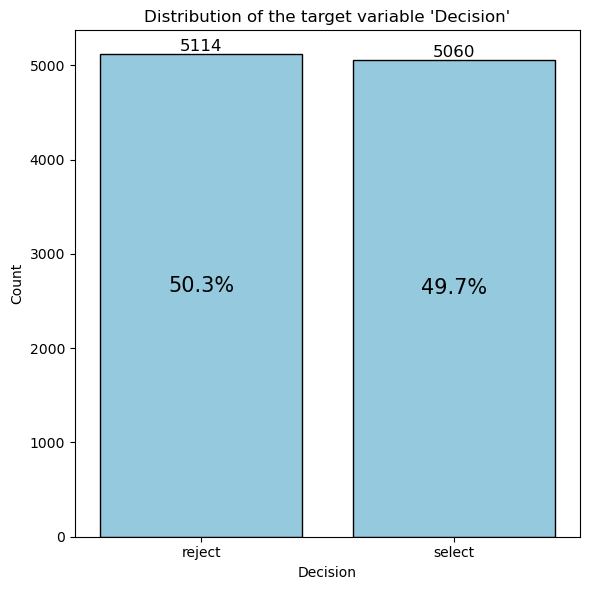

In [353]:
# visualize the distribution of the target variable
print("Distribution of the target variable 'Decision':")
display(df['Decision'].value_counts())
print("\nPercentage:")
display(df['Decision'].value_counts(normalize=True) * 100)

# bar plot for the distribution of the target variable
plt.figure(figsize=(6, 6))
ax = sns.countplot(x='Decision', data=df, color="skyblue", edgecolor="black", linewidth=1)

total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    pct = count / total * 100
    ax.annotate(
        f"{count}",
        (p.get_x() + p.get_width() / 2, count),
        ha="center",
        va="bottom",
        fontsize=12,
    )
    ax.annotate(
        f"{pct:.1f}%",
        (p.get_x() + p.get_width() / 2, count/2),
        ha="center",
        va="bottom",
        fontsize=15,
    )

ax.set_title("Distribution of the target variable 'Decision'")
ax.set_xlabel("Decision")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

Output interpretation: This output and bar plot show that the `Decision` target is nearly balanced, with 5,114 `reject` samples and 5,060 `select` samples. This means there is no severe class imbalance issue for this binary classification task. Because the labels are balanced, the models are less likely to simply favor one class. However, accuracy alone is still not enough for this project. In resume screening, a false positive means the model recommends a weak candidate, and a false negative means the model misses a potentially strong candidate. Therefore, F1-score is useful because it considers both Precision and Recall so we will also use Precision, Recall, and F1-score to evaluate the classification models.

## 4. Basic Text Statistics

### Raw Text Length Distribution Analysis (histograms)

In [354]:
# create new columns for the length of resumes and job descriptions
df['resume_len'] = df['Resume'].str.split().str.len()
df['jd_len'] = df['Job_Description'].str.split().str.len()

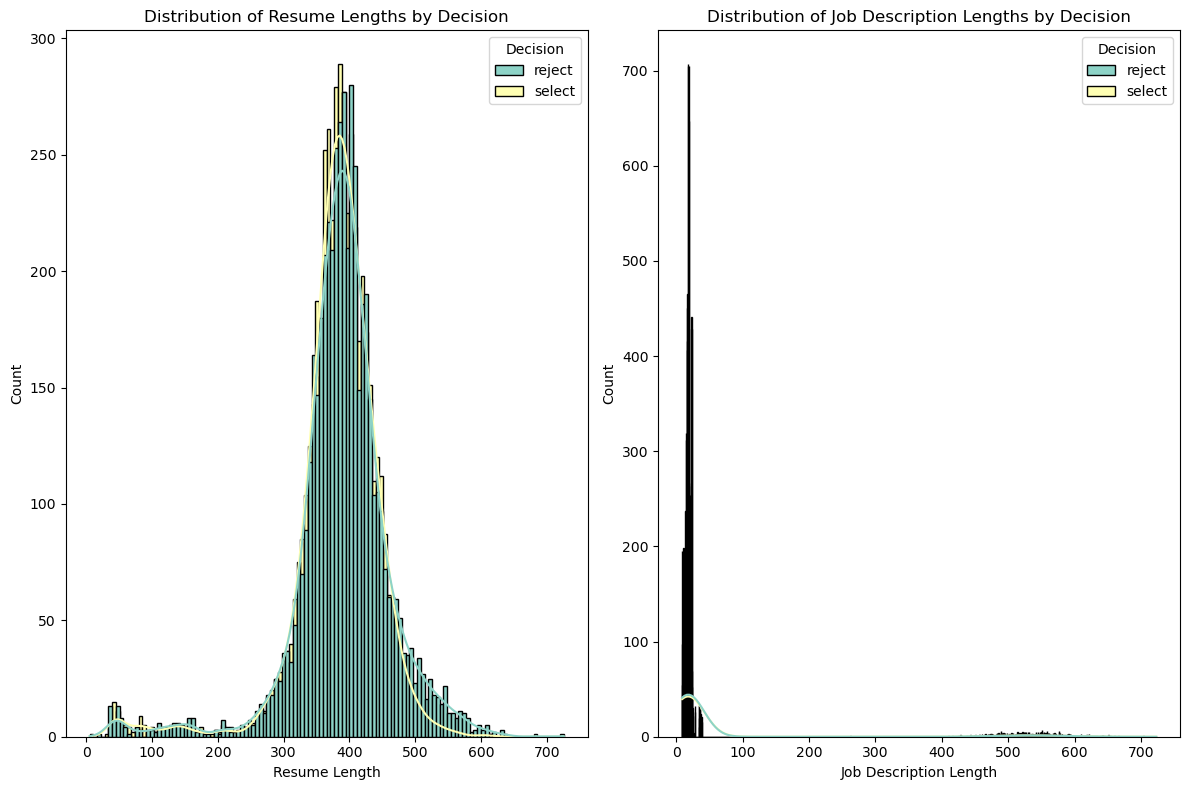

In [355]:
# Visualize the distributions of resume and job description lengths for accepted vs rejected applications using histograms
plt.figure(figsize=(12, 8))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='resume_len', hue='Decision', kde=True, palette='Set3', alpha=1, edgecolor="black", linewidth=1)
plt.title('Distribution of Resume Lengths by Decision')
plt.xlabel('Resume Length')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='jd_len', hue='Decision', kde=True, palette='Set3', alpha=1, edgecolor="black", linewidth=1)
plt.title('Distribution of Job Description Lengths by Decision')
plt.xlabel('Job Description Length')
plt.ylabel('Count') 

# Adjust layout and display the plots
plt.tight_layout()
plt.show()


Output interpretation: These histograms show that resume length and job-description length distributions overlap heavily between selected and rejected candidates. Although resume lengths are approximately bell-shaped while job-description lengths are more right-skewed, neither feature shows strong separation between hiring outcomes. This suggests that document length alone is unlikely to be a strong predictive feature. Therefore, the project prioritizes alignment-based features such as overlap ratio, cosine similarity, and skill matching, which are more directly connected to resume-job fit.

### Average resume & JD length
**before preprocessing Resume & JD data**

resume_len                       jd_len                   
                mean median        std       mean median         std
Decision                                                            
reject    389.616152  391.0  73.295847  52.425499   18.0  129.009892
select    382.542292  387.0  66.148703  54.523123   18.0  132.548733

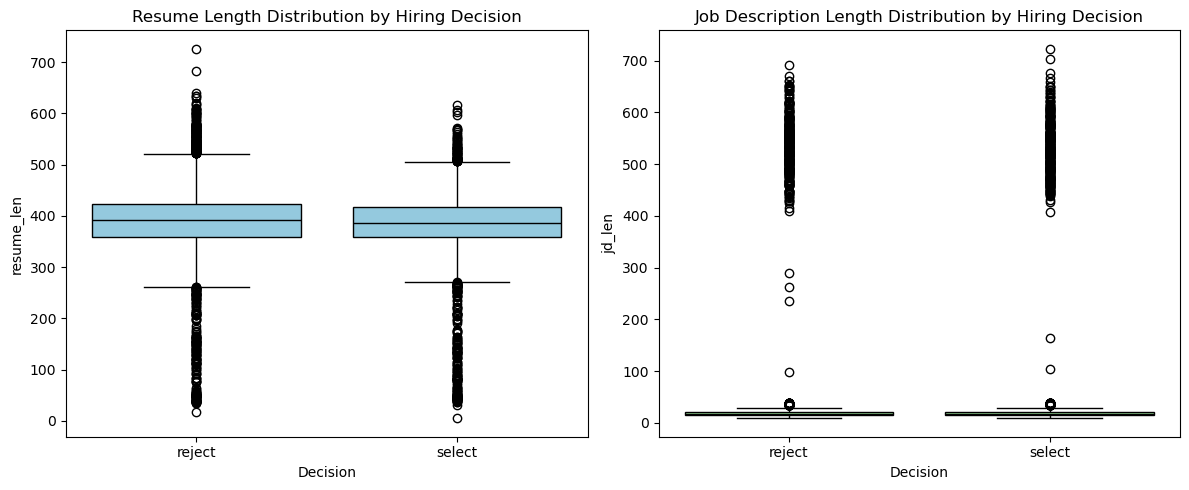

In [356]:
# visualize average length of resumes and job descriptions for accepted vs rejected applications

# group by the target variable and calculate the mean, median, and standard deviation of resume and job description lengths
display(df.groupby('Decision')[['resume_len', 'jd_len']].agg(['mean', 'median', 'std']))

# box plots to visualize the distribution of resume and job description lengths for accepted vs rejected applications
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='Decision', y='resume_len', data=df, color="skyblue", linecolor="black", linewidth=1)
plt.title("Resume Length Distribution by Hiring Decision")

plt.subplot(1, 2, 2)
sns.boxplot(x='Decision', y='jd_len', data=df, color="lightgreen", linecolor="black", linewidth=1)
plt.title("Job Description Length Distribution by Hiring Decision")

plt.tight_layout()
plt.show()

Output interpretation: These outputs and box plots show that the average resume length and average job-description length differ only slightly between `reject` and `select` classes. The distributions overlap heavily and both features contain many outliers, suggesting substantial variability within each class. This suggests that resume length and job-description length alone are unlikely to strongly discriminate between hiring outcomes. Therefore, downstream models should rely more on textual alignment and skill-related features rather than document length itself.

Takeaway: This analysis suggests that raw document length is probably a weak standalone feature for resume-job matching. More informative features may come from lexical overlap, semantic similarity, and technical skill alignment between resumes and job descriptions.

## 5. Text Preprocessing

### Preprocessing Resume & JD textual data
**Used `nltk.word_tokenize()`**

In [357]:
# text preprocessing for resumes and job descriptions

def preprocess_text(df: pd.DataFrame, text_column: list) -> pd.DataFrame:
    for col in text_column:
        # convert to lowercase
        df[col] = df[col].str.lower()
        
        # split the text and punctuation into tokens using NLTK's word_tokenize
        df[col + '_tokens'] = df[col].apply(lambda x: nltk.word_tokenize(x))
        # remove punctuation
        df[col + '_tokens'] = df[col + '_tokens'].apply(lambda tokens: [word for word in tokens if word not in string.punctuation]) 
        
        # remove stop words
        stop_words = set(nltk.corpus.stopwords.words('english'))
        df[col + '_tokens'] = df[col + '_tokens'].apply(lambda tokens: [word for word in tokens if word not in stop_words])
        
    return df, [text_column[i] + '_tokens' for i in range(len(text_column))]

In [358]:
# preprocess the text in the 'Resume' and 'Job_Description' columns
df, token_columns = preprocess_text(df, ['Resume', 'Job_Description'])
print("Tokenized columns:")
display(token_columns)

Tokenized columns:


['Resume_tokens', 'Job_Description_tokens']

In [359]:
# display the first few rows of the dataset after preprocessing
print("First few rows of the dataset after preprocessing:")
display(df.head())

First few rows of the dataset after preprocessing:


,Role,Resume,Decision,Reason_for_decision,Job_Description,resume_len,jd_len,Resume_tokens,Job_Description_tokens
0,E-commerce Specialist,here's a professional resume for jason jones:\...,reject,Lacked leadership skills for a senior position.,be part of a passionate team at the forefront ...,342,22,"['s, professional, resume, jason, jones, jason...","[part, passionate, team, forefront, machine, l..."
1,Game Developer,here's a professional resume for ann marshall:...,select,Strong technical skills in AI and ML.,help us build the next-generation products as ...,51,17,"['s, professional, resume, ann, marshall, ann,...","[help, us, build, next-generation, products, g..."
2,Human Resources Specialist,here's a professional resume for patrick mccla...,reject,Insufficient system design expertise for senio...,we need a human resources specialist to enhanc...,405,19,"['s, professional, resume, patrick, mcclain, p...","[need, human, resources, specialist, enhance, ..."
3,E-commerce Specialist,here's a professional resume for patricia gray...,select,Impressive leadership and communication abilit...,be part of a passionate team at the forefront ...,319,22,"['s, professional, resume, patricia, gray, pat...","[part, passionate, team, forefront, cloud, com..."
4,E-commerce Specialist,here's a professional resume for amanda gross:...,reject,Lacked leadership skills for a senior position.,we are looking for an experienced e-commerce s...,357,20,"['s, professional, resume, amanda, gross, aman...","[looking, experienced, e-commerce, specialist,..."


##### Average resume & JD length and length ratio
after preprocessing Resume & JD data using `nltk.word_tokenize()`

resume_tokens_len                   jd_tokens_len                    \
                      mean median        std          mean median        std   
Decision                                                                       
reject          284.267305  288.0  47.562860     34.201799   12.0  84.908139   
select          280.597233  285.0  45.626003     35.628854   12.0  87.428307   

          len_ratio                       
               mean     median       std  
Decision                                  
reject    21.953135  22.076923  8.628381  
select    21.442601  21.928571  8.165258

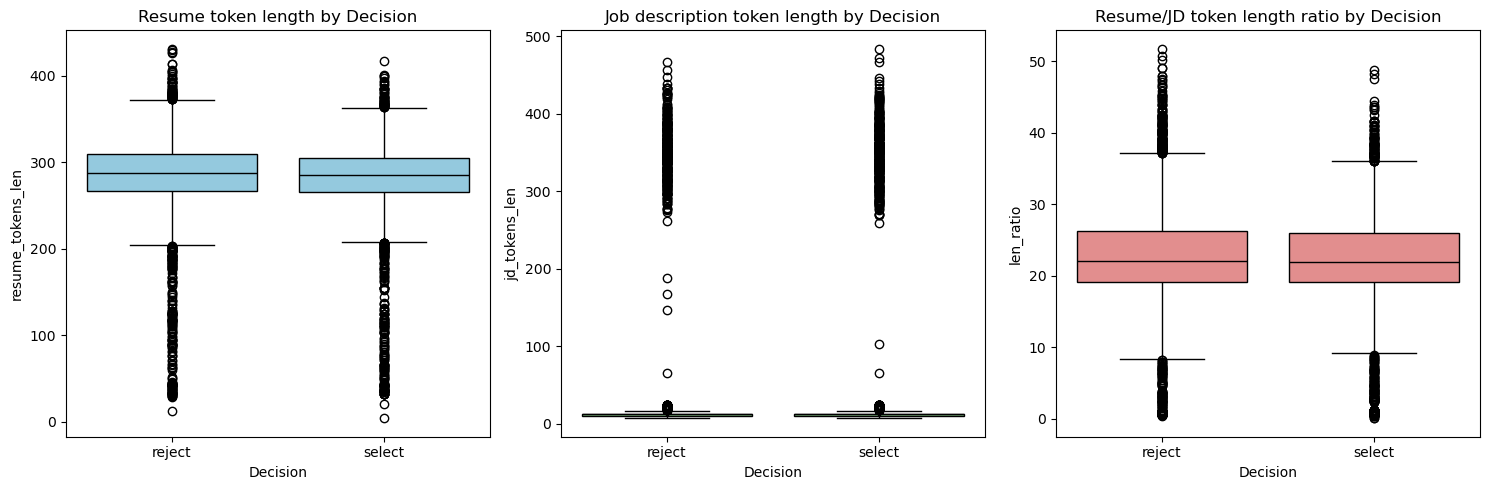

In [360]:
# visualize average length of resumes and job descriptions for accepted vs rejected applications after preprocessing

# create new columns for the length of tokenized resumes and job descriptions
df['resume_tokens_len'] = df['Resume_tokens'].str.len()
df['jd_tokens_len'] = df['Job_Description_tokens'].str.len()

# exploratory ratio feature: resume length relative to job-description length
df['len_ratio'] = df['resume_tokens_len'] / (df['jd_tokens_len'] + 1)

# group by the target variable and calculate the mean, median, and standard deviation
display(df.groupby('Decision')[['resume_tokens_len', 'jd_tokens_len', 'len_ratio']].agg(['mean', 'median', 'std']))

# box plots to visualize tokenized length distributions by decision class
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x='Decision', y='resume_tokens_len', data=df, color="skyblue", linecolor="black", linewidth=1)
plt.title('Resume token length by Decision')

plt.subplot(1, 3, 2)
sns.boxplot(x='Decision', y='jd_tokens_len', data=df, color="lightgreen", linecolor="black", linewidth=1)
plt.title('Job description token length by Decision')

plt.subplot(1, 3, 3)
sns.boxplot(x='Decision', y='len_ratio', data=df, color="lightcoral", linecolor="black", linewidth=1)
plt.title('Resume/JD token length ratio by Decision')

plt.tight_layout()
plt.show()

Output interpretation: After tokenization, punctuation removal, and stopword removal, the length differences between selected and rejected samples remain small. This suggests that the limited predictive value of document length is not only caused by stopwords or punctuation. The `len_ratio` feature is included as an exploratory check of resume length relative to job-description length, but it should be interpreted cautiously. If the ratio distributions still overlap heavily, then relative document length alone is also unlikely to strongly separate selected and rejected candidates. The main value of preprocessing is to create cleaner text representations for downstream BoW, TF-IDF, lexical and semantic alignment features, overlap ratio, cosine similarity, and skill matching features.

Takeaway: Basic document-level statistics suggest that resume length and job-description length alone are weak predictors of hiring outcomes. Therefore, the project focuses more heavily on alignment-based textual features and technical skill matching for downstream modeling.

## 6. Vocabulary and Word Frequency Analysis
**after preprocessing Resume & JD data**

##### Vocabulary size 
Used `nltk.word_tokenize()`

In [361]:
# Combine all the Resume_tokens and Job_Description_tokens into a single list of words for the entire dataset
filtered_words_re_jd = []
for col in token_columns:
    filtered_words_re_jd.extend(df[col].explode().dropna().tolist())

# Using the combined list of words to create a vocabulary set to capture all unique words across both resumes and job descriptions
vocabulary = set(filtered_words_re_jd)

# Calculate the size of the vocabulary using the set data structure which automatically handles duplicates and only keeps unique words
vocab_size = len(vocabulary)
# print the size of the vocabulary for both resumes and job descriptions combined
print(f"Vocabulary size combined (Resume + Job Description): {vocab_size}")

Vocabulary size combined (Resume + Job Description): 33647


Output Interpretation: The unique vocabulary size for the combined resume and job description text after removing punctuation and stopwords is 33,647, which is approximately three times the dataset size (10,174 samples). This indicates high vocabulary diversity and results in a high-dimensional sparse structure, introducing significant noise and overfitting risk when using simple Bag-of-Words (BoW) for training and testing models.

To address this, we will use TF-IDF instead of BoW. TF-IDF incorporates weighted word occurrences rather than raw counts, emphasizing relevant features and reducing the impact of word stuffing. This makes TF-IDF more robust than BoW for text classification tasks.

Additionally, to control model complexity and mitigate overfitting in high-dimensional sparse data, we will apply techniques such as SVD (Singular Value Decomposition) for dimensionality reduction or L1 regularization in logistic regression and Random Forest/XGBoost models. We will also set parameters like max_features, min_df, and max_df in vectorizers to filter low-frequency words and incorporate explicit features (e.g., overlap ratio, cosine similarity, skill matching) to supplement the model rather than relying solely on the full vocabulary.

In [374]:
import pandas as pd

vocab_summary = pd.DataFrame({
    "Statistic": [
        "Combined vocabulary size",
        "Resume vocabulary size",
        "Job-description vocabulary size",
        "Dataset size"
    ],
    "Value": [
        "33,647",
        "20,294",
        "2,999",
        "10,174"
    ]
})

vocab_summary.style.set_caption("Vocabulary Size Summary")

,Statistic,Value
0,Combined vocabulary size,"33,647"
1,Resume vocabulary size,"20,294"
2,Job-description vocabulary size,"2,999"
3,Dataset size,"10,174"


##### Word-frequency distributions & Analysis
- **Used `CountVectorizer()` to tokenize texts**

- Analyze if there are significant differences between decision classes (`reject` & `select`) for `Resume` and `Job_Description` to help consider the effect of features generated by BoW on classifying `Decision` labels.

In [363]:
# build arrays to store the resume and job description texts grouped by decision classes
selected_resumes = df[df['Decision'] == 'select']['Resume'].values
rejected_resumes = df[df['Decision'] == 'reject']['Resume'].values
selected_jds = df[df['Decision'] == 'select']['Job_Description'].values
rejected_jds = df[df['Decision'] == 'reject']['Job_Description'].values

In [364]:
# using CountVectorizer() to calculate the frequency of each word in vocabulary for resume and job description for accepted vs rejected applications

# ============================================================
# RESUME WORD-FREQUENCY ANALYSIS
# ============================================================

# 1. Fit CountVectorizer on ALL resumes (selected + rejected combined) to get unified vocabulary
all_resumes = np.concatenate([selected_resumes, rejected_resumes])
resume_vectorizer = CountVectorizer(
    lowercase=True, 
    stop_words='english', 
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z0-9]*\b',  # capture words starting with letter, followed by letters/digits; excludes pure digits and punctuation
    max_features=None  # limit to top 1000 words for clarity
)

# Fit the CountVectorizer on the combined set of resumes to learn the vocabulary from the entire dataset, ensuring that the same vocabulary is used for both selected and rejected resumes when transforming them into BoW matrices. This allows for a direct comparison of word frequencies between the two classes using the same set of features (words) in the resulting BoW matrices.
resume_vectorizer.fit(all_resumes)

# 2. Transform selected and rejected resumes separately using the same vocabulary
selected_resumes_bow = resume_vectorizer.transform(selected_resumes)
rejected_resumes_bow = resume_vectorizer.transform(rejected_resumes)

# 3. Calculate word frequencies for each class
resume_feature_names = resume_vectorizer.get_feature_names_out()
selected_resume_freq = selected_resumes_bow.sum(axis=0).A1
rejected_resume_freq = rejected_resumes_bow.sum(axis=0).A1

# 4. Create a DataFrame to compare word frequencies between classes
resume_freq_df = pd.DataFrame({
    'word': resume_feature_names,
    'select_count': selected_resume_freq,
    'reject_count': rejected_resume_freq
})

# Display the first few rows of the resume frequency DataFrame
print("First few rows of the resume frequency DataFrame:")
display(resume_freq_df.head())

# Display statistics
print(f"Resume vocabulary size (unified): {len(resume_feature_names)}")
print(f"BoW matrix shape for selected resumes: {selected_resumes_bow.shape}")
print(f"BoW matrix shape for rejected resumes: {rejected_resumes_bow.shape}")

# ============================================================
# JOB DESCRIPTION WORD-FREQUENCY ANALYSIS
# ============================================================

# 1. Fit CountVectorizer on ALL job descriptions (selected + rejected combined) to get unified vocabulary
all_jds = np.concatenate([selected_jds, rejected_jds])
jd_vectorizer = CountVectorizer(
    lowercase=True, 
    stop_words='english', 
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z0-9]*\b',  # capture words starting with letter, followed by letters/digits; excludes pure digits and punctuation
    max_features=None  # limit to top 1000 words for clarity
)
jd_vectorizer.fit(all_jds)

# 2. Transform selected and rejected job descriptions separately using the same vocabulary
selected_jds_bow = jd_vectorizer.transform(selected_jds)
rejected_jds_bow = jd_vectorizer.transform(rejected_jds)

# 3. Calculate word frequencies for each class
jd_feature_names = jd_vectorizer.get_feature_names_out()
selected_jd_freq = selected_jds_bow.sum(axis=0).A1
rejected_jd_freq = rejected_jds_bow.sum(axis=0).A1

# 4. Create a DataFrame to compare word frequencies between classes
jd_freq_df = pd.DataFrame({
    'word': jd_feature_names,
    'select_count': selected_jd_freq,
    'reject_count': rejected_jd_freq
})

# Display the first few rows of the job description frequency DataFrame
print("First few rows of the job description frequency DataFrame:")
display(jd_freq_df.head())

# Display statistics
print(f"\nJob Description vocabulary size (unified): {len(jd_feature_names)}")
print(f"BoW matrix shape for selected job descriptions: {selected_jds_bow.shape}")
print(f"BoW matrix shape for rejected job descriptions: {rejected_jds_bow.shape}")

First few rows of the resume frequency DataFrame:


,word,select_count,reject_count
0,a11y,3,2
1,aa,0,1
2,aaa,75,71
3,aaai,47,27
4,aad,1,1


Resume vocabulary size (unified): 20294
BoW matrix shape for selected resumes: (5060, 20294)
BoW matrix shape for rejected resumes: (5114, 20294)
First few rows of the job description frequency DataFrame:


,word,select_count,reject_count
0,a11y,0,1
1,abilities,190,3
2,ability,853,794
3,able,47,46
4,abstraction,0,1



Job Description vocabulary size (unified): 2999
BoW matrix shape for selected job descriptions: (5060, 2999)
BoW matrix shape for rejected job descriptions: (5114, 2999)


Output interpretation: The Bag-of-Words vocabulary for resumes is substantially larger than the vocabulary for job descriptions, indicating that resumes contain more diverse and individualized language. This creates a high-dimensional sparse feature space, where many words appear only a few times across the dataset. Such sparsity may increase noise and overfitting risk when using raw Bag-of-Words features directly. In addition, selected and rejected resumes share many common high-frequency words, suggesting that raw word frequency alone may not strongly separate hiring outcomes. These observations motivate the use of TF-IDF weighting and alignment-based features such as overlap ratio, cosine similarity, and skill matching instead of relying purely on raw word counts.   

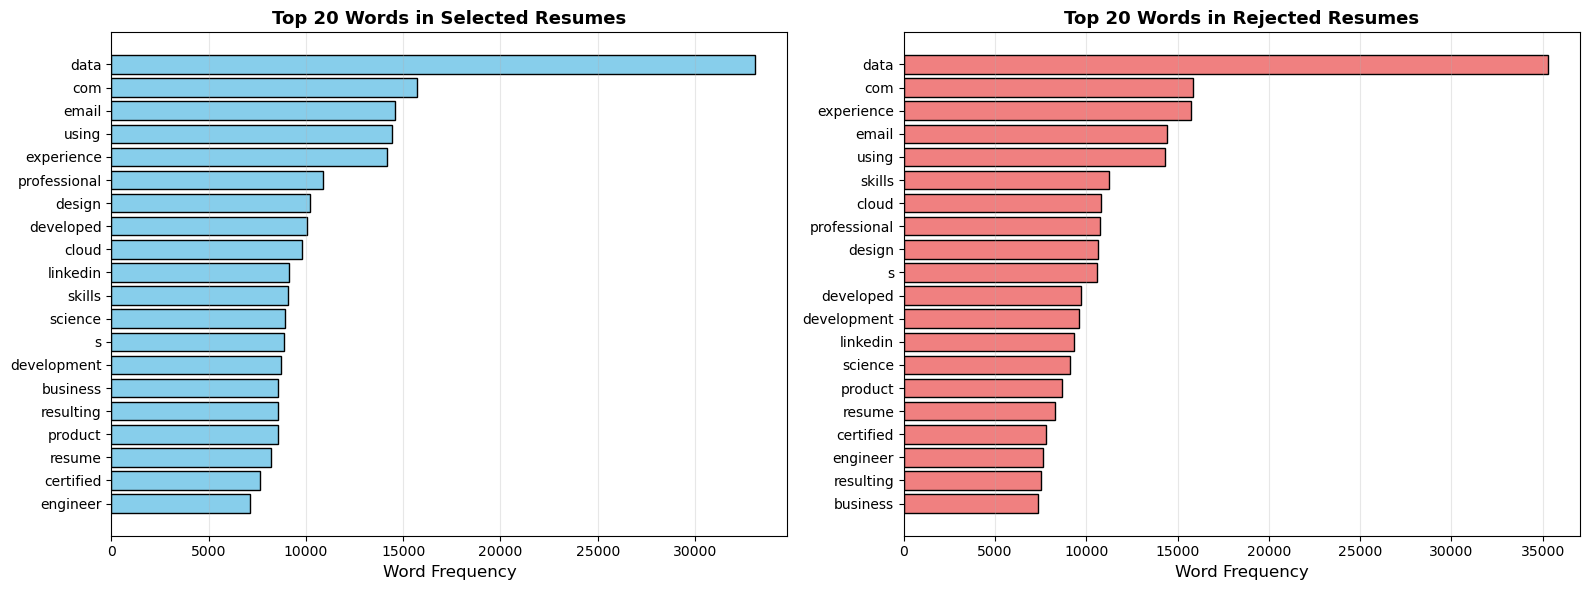

Resume word frequency statistics:
       select_count  reject_count
count  20294.000000  20294.000000
mean      69.253474     70.750961
std      528.348349    540.768964
min        0.000000      0.000000
25%        0.000000      0.000000
50%        1.000000      1.000000
75%        5.000000      6.000000
max    33102.000000  35279.000000


In [365]:
# Visualize top words in resumes by decision class

# Get top 20 words by selected resume count
top_resume_words = resume_freq_df.nlargest(20, 'select_count')

# Create side-by-side bar plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot for selected resumes
top_resume_words_sorted = top_resume_words.sort_values('select_count')
axes[0].barh(top_resume_words_sorted['word'], top_resume_words_sorted['select_count'], color='skyblue', edgecolor='black')
axes[0].set_xlabel('Word Frequency', fontsize=12)
axes[0].set_title('Top 20 Words in Selected Resumes', fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Plot for rejected resumes
top_rejected_resumes = resume_freq_df.nlargest(20, 'reject_count')
top_rejected_resumes_sorted = top_rejected_resumes.sort_values('reject_count')
axes[1].barh(top_rejected_resumes_sorted['word'], top_rejected_resumes_sorted['reject_count'], color='lightcoral', edgecolor='black')
axes[1].set_xlabel('Word Frequency', fontsize=12)
axes[1].set_title('Top 20 Words in Rejected Resumes', fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Display comparison statistics
print("Resume word frequency statistics:")
print(resume_freq_df.describe())


Output interpretation: These plots show the most frequent words in selected and rejected resumes. This suggests that simple word frequency alone may not be sufficient to clearly separate selected candidates from rejected candidates, because many common resume terms appear frequently in both classes. Both groups share many high-frequency terms, such as `data`, `com`, `email`, `experience`, `skills`, `cloud`, `design`, and `developed`. This suggests that simple word frequency alone may not be sufficient to clearly separate selected candidates from rejected candidates, because many common resume terms appear frequently in both classes.

The frequency statistics also show a highly sparse and skewed vocabulary distribution. Although the resume vocabulary contains 20,294 terms, the median word count is only 1 for both selected and rejected resumes, and the 75th percentile is only 5 or 6. At the same time, the maximum counts are extremely large, with `data` appearing over 33,000 times in selected resumes and over 35,000 times in rejected resumes. This suggests that a small number of generic terms dominate the BoW representation, while most words appear rarely.

This motivates using TF-IDF weighting, since TF-IDF reduces the influence of extremely common words while giving more importance to informative and discriminative terms. It also motivates adding explicit resume-job matching features, such as overlap ratio, cosine similarity, and skill matching, because raw word frequency does not directly measure whether a resume aligns with a specific job description. In addition, frequency-based methods struggle to capture semantic similarity between different but related phrases.     


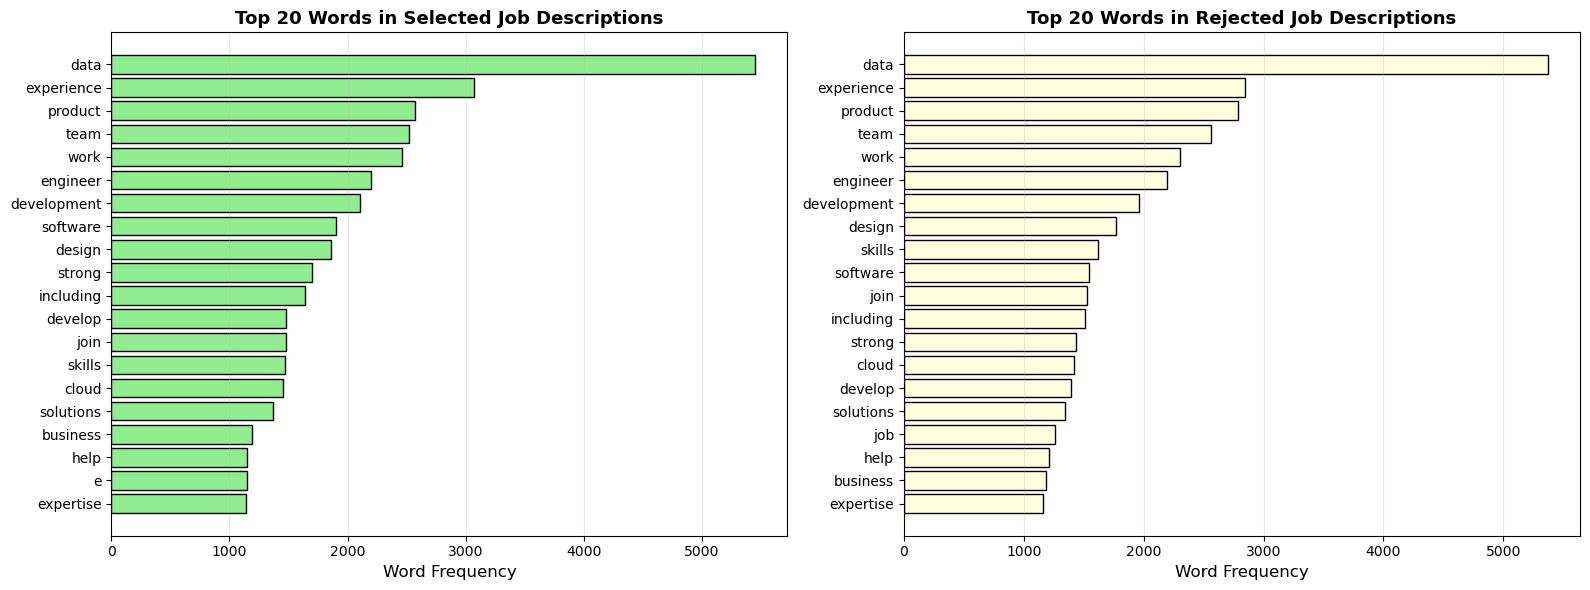

Job Description word frequency statistics:
       select_count  reject_count
count   2999.000000   2999.000000
mean      60.021674     58.290430
std      217.690756    213.174292
min        0.000000      0.000000
25%        1.000000      1.000000
50%        3.000000      3.000000
75%       19.000000     19.000000
max     5452.000000   5371.000000


In [366]:
# Visualize top words in job descriptions by decision class

# Get top 20 words by selected job description count
top_jd_words = jd_freq_df.nlargest(20, 'select_count')

# Create side-by-side bar plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot for selected job descriptions
top_jd_words_sorted = top_jd_words.sort_values('select_count')
axes[0].barh(top_jd_words_sorted['word'], top_jd_words_sorted['select_count'], color='lightgreen', edgecolor='black')
axes[0].set_xlabel('Word Frequency', fontsize=12)
axes[0].set_title('Top 20 Words in Selected Job Descriptions', fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Plot for rejected job descriptions
top_rejected_jds = jd_freq_df.nlargest(20, 'reject_count')
top_rejected_jds_sorted = top_rejected_jds.sort_values('reject_count')
axes[1].barh(top_rejected_jds_sorted['word'], top_rejected_jds_sorted['reject_count'], color='lightyellow', edgecolor='black')
axes[1].set_xlabel('Word Frequency', fontsize=12)
axes[1].set_title('Top 20 Words in Rejected Job Descriptions', fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Display comparison statistics
print("Job Description word frequency statistics:")
print(jd_freq_df.describe())


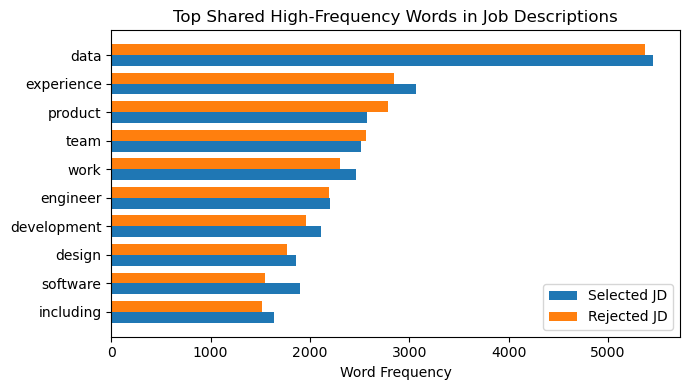

In [367]:
# Compact grouped bar chart for shared high-frequency JD words

import numpy as np
import matplotlib.pyplot as plt

# choose top shared high-frequency words based on total frequency
jd_freq_df["total_count"] = jd_freq_df["select_count"] + jd_freq_df["reject_count"]

top_shared_jd_words = (
    jd_freq_df
    .sort_values("total_count", ascending=False)
    .head(10)
    .copy()
)

# reverse order so largest appears at the top in horizontal bar chart
top_shared_jd_words = top_shared_jd_words.iloc[::-1]

words = top_shared_jd_words["word"]
selected_counts = top_shared_jd_words["select_count"]
rejected_counts = top_shared_jd_words["reject_count"]

y = np.arange(len(words))
bar_height = 0.38

plt.figure(figsize=(7, 4))

plt.barh(
    y - bar_height / 2,
    selected_counts,
    height=bar_height,
    label="Selected JD"
)

plt.barh(
    y + bar_height / 2,
    rejected_counts,
    height=bar_height,
    label="Rejected JD"
)

plt.yticks(y, words)
plt.xlabel("Word Frequency")
plt.title("Top Shared High-Frequency Words in Job Descriptions")
plt.legend()
plt.tight_layout()

# optional: save figure for report
plt.savefig("top_shared_jd_words_grouped_bar.png", dpi=300, bbox_inches="tight")

plt.show()

Output interpretation: These plots show the most frequent words in job descriptions associated with selected and rejected candidates. The two groups share many of the same high-frequency terms, including `data`, `experience`, `product`, `team`, `work`, `engineer`, `development`, `software`, `design`, and `skills`. This suggests that job descriptions across selected and rejected samples are lexically very similar at the raw word-frequency level.

The summary statistics also show a highly skewed word-frequency distribution. Although the job-description vocabulary contains 2,999 terms, the median word count is only 3 for both selected and rejected job descriptions, and the 75th percentile is 19 for both groups. At the same time, the most frequent word appears more than 5,000 times in each class. This indicates that a small set of generic job-description terms dominates the BoW representation.

Compared with resumes, job descriptions have a much smaller vocabulary, but they still show the same sparsity and frequency-skew issue. Therefore, raw BoW counts alone are unlikely to fully capture resume-job fit. This motivates using TF-IDF weighting and explicit matching features such as overlap ratio, cosine similarity, and skill matching to measure alignment between a specific resume and a specific job description.   


In [368]:
# Analyze word frequency differences between selected and rejected classes

# For resumes: calculate the ratio of selected vs rejected word frequencies
resume_freq_df['select_vs_reject_ratio'] = (resume_freq_df['select_count'] + 1) / (resume_freq_df['reject_count'] + 1)

# Words that appear more frequently in selected resumes (high ratio)
words_favoring_selected_resumes = resume_freq_df.nlargest(15, 'select_vs_reject_ratio')[['word', 'select_count', 'reject_count', 'select_vs_reject_ratio']]
print("Top 15 words that favor SELECTED resumes (appear more in selected than rejected):")
display(words_favoring_selected_resumes)

# Words that appear more frequently in rejected resumes (low ratio)
words_favoring_rejected_resumes = resume_freq_df.nsmallest(15, 'select_vs_reject_ratio')[['word', 'select_count', 'reject_count', 'select_vs_reject_ratio']]
print("\nTop 15 words that favor REJECTED resumes (appear more in rejected than selected):")
display(words_favoring_rejected_resumes)

# For job descriptions: calculate the ratio of selected vs rejected word frequencies
jd_freq_df['select_vs_reject_ratio'] = (jd_freq_df['select_count'] + 1) / (jd_freq_df['reject_count'] + 1)

# Words that appear more frequently in selected job descriptions
words_favoring_selected_jds = jd_freq_df.nlargest(15, 'select_vs_reject_ratio')[['word', 'select_count', 'reject_count', 'select_vs_reject_ratio']]
print("\nTop 15 words that favor SELECTED job descriptions (appear more in selected than rejected):")
display(words_favoring_selected_jds)

# Words that appear more frequently in rejected job descriptions
words_favoring_rejected_jds = jd_freq_df.nsmallest(15, 'select_vs_reject_ratio')[['word', 'select_count', 'reject_count', 'select_vs_reject_ratio']]
print("\nTop 15 words that favor REJECTED job descriptions (appear more in rejected than selected):")
display(words_favoring_rejected_jds)


Top 15 words that favor SELECTED resumes (appear more in selected than rejected):


,word,select_count,reject_count,select_vs_reject_ratio
13923,noteworthy,368,0,369.000000
14858,poised,222,0,223.000000
11011,known,111,0,112.000000
17603,spans,69,0,70.000000
15191,prospect,65,0,66.000000
8028,hindi,99,1,50.000000
6321,equipped,191,3,48.000000
2453,brings,92,1,46.500000
15180,property,40,0,41.000000
8281,ideal,277,6,39.714286



Top 15 words that favor REJECTED resumes (appear more in rejected than selected):


,word,select_count,reject_count,select_vs_reject_ratio
11192,lack,0,1096,0.000912
18057,struggled,0,1092,0.000915
15423,raised,0,760,0.001314
11193,lacked,0,510,0.001957
5465,did,0,505,0.001976
19268,unfamiliar,0,409,0.002439
5476,difficulty,1,654,0.003053
3037,certain,0,317,0.003145
3951,concern,0,234,0.004255
8566,insufficient,0,226,0.004405



Top 15 words that favor SELECTED job descriptions (appear more in selected than rejected):


,word,select_count,reject_count,select_vs_reject_ratio
436,clearly,198,0,199.000000
988,exhibited,186,0,187.000000
1311,impressive,176,0,177.000000
2496,showed,165,0,166.000000
492,communicated,196,1,98.500000
921,enthusiasm,165,1,83.000000
1,abilities,190,3,47.750000
2034,potential,176,8,19.666667
1191,great,174,12,13.461538
912,enhancements,10,0,11.000000



Top 15 words that favor REJECTED job descriptions (appear more in rejected than selected):


,word,select_count,reject_count,select_vs_reject_ratio
1495,lacked,0,206,0.004831
2641,struggled,0,202,0.004926
1380,insufficient,0,180,0.005525
1549,limited,9,205,0.048544
2438,sdk,0,14,0.066667
1828,oculus,0,10,0.090909
793,different,0,7,0.125000
1772,needed,31,252,0.126482
1668,mediums,0,6,0.142857
2062,prepare,0,6,0.142857


Output interpretation: This ratio analysis identifies words that appear disproportionately more often in selected or rejected samples. In resumes, words such as `noteworthy`, `poised`, `known`, `equipped`, and `ideal` appear much more frequently in selected samples, while words such as `lack`, `struggled`, `lacked`, `unfamiliar`, `difficulty`, `insufficient`, and `limited` appear much more frequently in rejected samples.

A similar pattern appears in job descriptions. Words associated with selected samples include positive evaluation terms such as `clearly`, `exhibited`, `impressive`, `communicated`, `enthusiasm`, `abilities`, and `potential`. In contrast, rejected samples include more negative or limitation-related words such as `lacked`, `struggled`, `insufficient`, `limited`, and `needed`.

This suggests that the dataset contains lexical patterns associated with selection outcomes. However, many of these words appear to reflect the `reason_for_decision`-style language or evaluative wording rather than pure resume-job skill alignment. Therefore, these features may help classification, but they should be interpreted carefully because they may capture label-associated language patterns rather than generalizable hiring qualifications.  

Word-frequency distributions & analysis summary: Overall, the word-frequency analysis shows that raw BoW features contain useful predictive signals, but they also have important limitations. The most frequent words in selected and rejected resumes and job descriptions are highly similar, suggesting that common word frequency alone does not clearly separate the two classes. At the same time, the ratio analysis reveals class-associated words that strongly favor selected or rejected samples.

These findings motivate using TF-IDF rather than raw BoW counts, because TF-IDF can reduce the influence of overly common terms. They also motivate adding explicit resume-job alignment features such as overlap ratio, cosine similarity, and skill matching, because word frequency alone does not directly measure whether a specific resume matches a specific job description.

Finally, some highly class-associated words may reflect evaluative or label-related wording rather than transferable skill information. This highlights the need for careful error analysis and interpretation when using text features for hiring-related prediction.  

## 7. Skill Frequency Analysis
**Raw data before data preprocessing**

### Common technical skills

In [369]:

# Define a list of common technical skills to check for in resumes and job descriptions
technical_skills = [
    "python", "sql", "java", "javascript", "r",
    "aws", "azure", "docker", "kubernetes",
    "tensorflow", "pytorch", "scikit-learn",
    "deep", "learning", "nlp","spark", "vba",
    "hadoop", "tableau","excel", "react", 
    "node", "git", "linux", "machine",
    "nodejs", "powerbi", "cnn", "lstm", 
    "api", "rest", "graphql", "ci/cd", "jenkins",
    "airflow", "kafka", "redis", "mongodb",
    "postgresql", "mysql", "oracle", "snowflake",
    "sas", "matlab", "scala", "go", "ruby",
    "c++", "c#", "flutter", "dart", "swift",
    "android", "ios", "angular", "vue", "django",
    "flask", "fastapi", "spring", "hibernate",
]

### frequency of common technical skills 
**Raw data before data preprocessing**

In [370]:
# visualize the frequency of technical skills in resumes and job descriptions by decision class

# For each skill, calculate the percentage of selected and rejected resumes and job descriptions that mention the skill, as well as the percentage of cases where both the resume and job description mention the skill for selected vs rejected applications.
# lowercase the resume and job description texts to avoid repeated lowercasing inside row-wise apply calls, which can be inefficient.
resume_text = df["Resume"].fillna("").str.lower()
jd_text = df["Job_Description"].fillna("").str.lower()

# store the results in a list of dictionaries and then convert it to a DataFrame for easier analysis and visualization.
skill_rows = []

# Loop through each skill and calculate the required percentages for selected vs rejected applications
for skill in technical_skills:
    # Match whole skills rather than substrings. For example, this avoids matching 'r' inside 'manager'.
    pattern = r"(?<![a-zA-Z0-9])" + re.escape(skill) + r"(?![a-zA-Z0-9])"

    # Vectorized string matching is much faster than df.apply(lambda ...).
    # Create boolean Series indicating whether each resume and job description contains the skill using str.contains with the defined regex pattern.
    resume_has_skill = resume_text.str.contains(pattern, regex=True, na=False)
    jd_has_skill = jd_text.str.contains(pattern, regex=True, na=False)
    both_have_skill = resume_has_skill & jd_has_skill

    # Calculate percentages for selected vs rejected applications
    for decision in ["select", "reject"]:
        # Create a boolean mask for the current decision class
        mask = df["Decision"] == decision

        # Append the calculated percentages to the skill_rows list as a dictionary
        skill_rows.append({
            "skill": skill,
            "decision": decision,
            # Calculate the percentage of resumes that mention the skill for the current decision class by dividing the count of resumes that mention the skill by the total number of resumes in that decision class and multiplying by 100 to get a percentage.
            "resume_skill_pct": resume_has_skill[mask].mean() * 100, 
            # Calculate the percentage of job descriptions that mention the skill for the current decision class by dividing the count of job descriptions that mention the skill by the total number of job descriptions in that decision class and multiplying by 100 to get a percentage.
            "jd_skill_pct": jd_has_skill[mask].mean() * 100,
            # Calculate the percentage of cases where both the resume and job description mention the skill for the current decision class by dividing the count of cases where both mention the skill by the total number of cases in that decision class and multiplying by 100 to get a percentage.
            "resume_jd_skill_match_pct": both_have_skill[mask].mean() * 100
        })

# Convert the list of dictionaries to a DataFrame for analysis and visualization
skill_freq_df = pd.DataFrame(skill_rows)

# Display the first 20 rows of the technical skill frequency DataFrame
print("First 20 rows of the Technical skill frequency DataFrame:")
display(skill_freq_df.head(20))
# Display statistics for the skill frequency DataFrame to understand the distribution of skill mentions across selected vs rejected applications.
print("Technical skill frequency statistics:")
display(skill_freq_df.describe())

First 20 rows of the Technical skill frequency DataFrame:


,skill,decision,resume_skill_pct,jd_skill_pct,resume_jd_skill_match_pct
0,python,select,48.577075,6.660079,6.185771
1,python,reject,52.033633,6.257333,5.651154
2,sql,select,23.399209,2.529644,2.252964
3,sql,reject,24.149394,2.678921,2.287837
4,java,select,21.857708,4.110672,3.557312
5,java,reject,23.875636,3.597966,2.894016
6,javascript,select,20.059289,3.023715,2.826087
7,javascript,reject,20.473211,3.011341,2.874462
8,r,select,12.569170,1.067194,0.889328
9,r,reject,13.648807,1.173250,1.036371


Technical skill frequency statistics:


,resume_skill_pct,jd_skill_pct,resume_jd_skill_match_pct
count,122.000000,122.000000,122.000000
mean,10.058776,1.472467,0.952956
std,10.707782,2.261441,1.590192
min,0.000000,0.000000,0.000000
25%,2.233202,0.117638,0.044310
50%,5.986380,0.452146,0.235902
75%,14.875831,2.258506,1.162930
max,52.033633,11.561265,7.727273


Output interpretation: This output summarizes how often selected and rejected samples contain common technical skills in resumes, job descriptions, and matched resume-job pairs. The `resume_skill_pct` values are generally much higher than the `jd_skill_pct` values, which suggests that resumes mention technical skills more frequently than job descriptions. For example, Python appears in 48.58% of selected resumes and 52.03% of rejected resumes, but only in about 6% of job descriptions. This pattern is reasonable because resumes usually list a broad range of candidate skills, while job descriptions tend to mention only a smaller set of required or preferred skills.

The most important column for resume-job matching is `resume_jd_skill_match_pct`, which measures the percentage of resume-job pairs where the same skill appears in both the resume and the job description. These matched-skill percentages are relatively low overall, with a mean of 1.83% and a median of 1.53%. This indicates that exact technical skill overlap is not very common across the predefined skill list.

The selected and rejected groups show only small differences for many individual skills. For example, Python has a slightly higher matched-skill rate in selected samples than rejected samples, while SQL and JavaScript are similar across both classes. This suggests that individual technical skill matches alone are unlikely to strongly distinguish selected candidates from rejected candidates.

However, skill matching can still provide useful supporting signals when combined with broader text features such as TF-IDF, overlap ratio, and cosine similarity. These features capture different aspects of resume-job alignment, while explicit skill matching provides an interpretable measure of technical fit.


### compare selected vs rejected classes
**Raw data before data preprocessing**

Skills that favor SELECTED applications (positive difference in resume-JD skill match percentage):


decision,skill,reject,select,select_minus_reject
24,java,2.89,3.56,0.66
4,aws,2.41,3.04,0.64
5,azure,1.62,2.21,0.59
7,c++,1.49,2.06,0.57
42,python,5.65,6.19,0.53
13,docker,0.72,1.17,0.44
8,ci/cd,0.49,0.83,0.34
26,jenkins,0.25,0.59,0.34
50,scala,0.18,0.45,0.28
40,postgresql,0.10,0.30,0.20


Skills that favor REJECTED applications (negative difference in resume-JD skill match percentage):


decision,skill,reject,select,select_minus_reject
2,angular,0.96,0.95,-0.01
30,linux,0.22,0.20,-0.02
19,go,0.08,0.06,-0.02
52,snowflake,0.02,0.00,-0.02
55,sql,2.29,2.25,-0.03
1,android,0.10,0.06,-0.04
25,javascript,2.87,2.83,-0.05
6,c#,0.29,0.24,-0.06
14,excel,0.20,0.14,-0.06
11,deep,1.15,1.09,-0.07


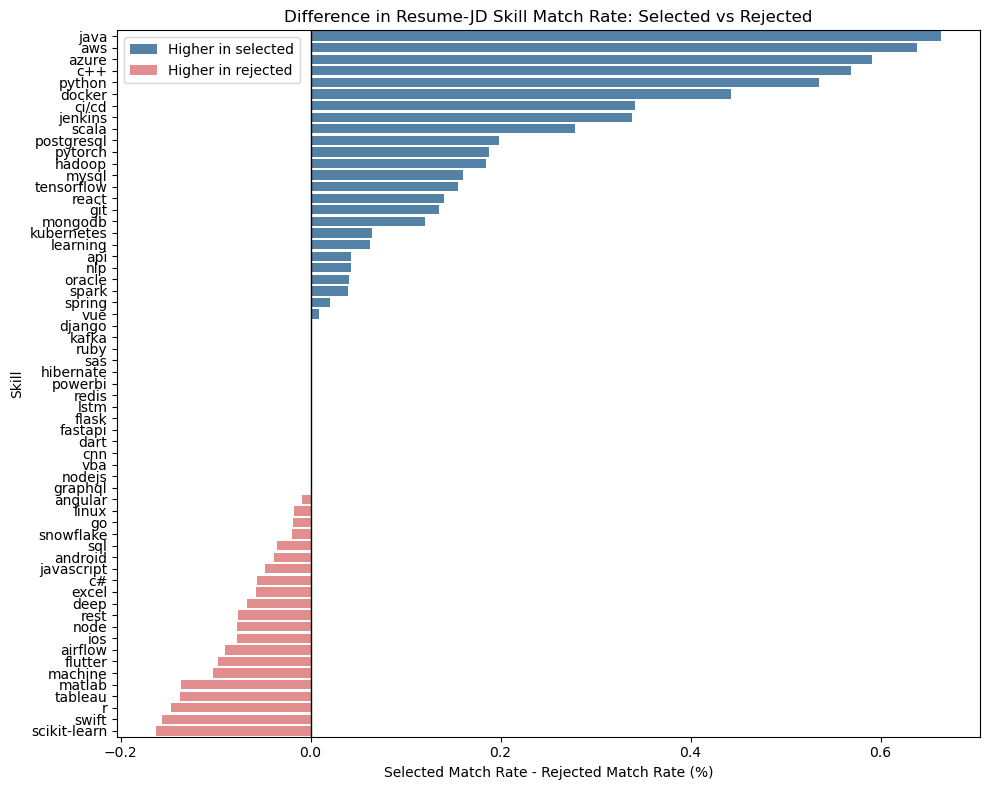

In [371]:
# Analyze common technical skills in resumes and job descriptions by decision class

# Create a pivot table to compare the resume-JD skill match percentage for selected vs rejected applications
skill_match_table = skill_freq_df.pivot(
    index="skill",
    columns="decision",
    values="resume_jd_skill_match_pct"
).reset_index()

# Calculate the difference in resume-JD skill match percentage between selected and rejected applications for each skill
skill_match_table["select_minus_reject"] = (
    skill_match_table["select"] - skill_match_table["reject"]
)

# Sort the table by the difference in match percentage to identify which skills have the largest positive difference (favoring selected applications) and which have the largest negative difference (favoring rejected applications).
skill_match_table = skill_match_table.sort_values(
    "select_minus_reject",
    ascending=False
)

# Display the skills that favor selected applications (positive difference)
print("Skills that favor SELECTED applications (positive difference in resume-JD skill match percentage):")
display(skill_match_table[skill_match_table["select_minus_reject"] > 0].round(2))
# Display the skills that favor rejected applications (negative difference)
print("Skills that favor REJECTED applications (negative difference in resume-JD skill match percentage):")
display(skill_match_table[skill_match_table["select_minus_reject"] < 0].round(2))

# Visualize the difference in resume-JD skill match percentage between selected and rejected applications for 
# the top skills that favor selected applications (positive difference) and 
# the top skills that favor rejected applications (negative difference) using a bar plot. 
# The x-axis will represent the difference in match percentage (selected minus rejected), and the y-axis will list the skills. 
# Positive values indicate skills that are more commonly matched in selected applications, 
# while negative values indicate skills that are more commonly matched in rejected applications.

plot_skills = skill_match_table.copy()
plot_skills["direction"] = plot_skills["select_minus_reject"].apply(
    lambda x: "Higher in selected" if x > 0 else "Higher in rejected"
)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=plot_skills,
    x="select_minus_reject",
    y="skill",
    hue="direction",
    palette={
        "Higher in selected": "steelblue",
        "Higher in rejected": "lightcoral"
    },
    dodge=False
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Difference in Resume-JD Skill Match Rate: Selected vs Rejected")
plt.xlabel("Selected Match Rate - Rejected Match Rate (%)")
plt.ylabel("Skill")
plt.legend(title="")
plt.tight_layout()
plt.show()


Output interpretation: This output compares resume-JD technical skill match rates between selected and rejected applications. Positive values indicate skills whose match rate is higher among selected applications, while negative values indicate skills whose match rate is higher among rejected applications.

Several skills have higher match rates among selected applications, including `java`, `aws`, `azure`, `python`, and `docker`. For example, Java has a match rate of 3.56% in selected applications and 2.89% in rejected applications, giving a positive difference of 0.66 percentage points. AWS, Azure, Python, and Docker show similar positive differences.

However, the overall magnitude of these differences is small. The largest positive difference is for `java`, with `select_minus_reject = 0.66`, which is still less than 1 percentage point. The negative differences are also small, ranging roughly from -0.16 to -0.02 percentage points. This suggests that individual technical skill matches alone are not strong enough to clearly separate selected and rejected candidates.

The plot also shows that some skills, such as `scikit-learn`, `r`, `power bi`, `tableau`, and `machine learning`, have slightly higher match rates among rejected applications. This should not be interpreted as these skills causing rejection. Instead, it suggests that simply matching an isolated technical skill is insufficient for hiring prediction; the broader resume-job alignment still matters.

Overall, explicit skill matching provides an interpretable supporting signal, but it should be combined with broader text-based features such as TF-IDF, overlap ratio, and cosine similarity to better capture candidate-job fit.


## 8. Lexical Alignment (Overlap Ratio) Analysis
**(after preprocessing resume and job-description text using `nltk.word_tokenize()`)**


For each resume-job description pair, the overlap ratio is defined as:

$$
\text{Overlap Ratio}(R_i, J_i) = \frac{|R_i \cap J_i|}{|J_i|}
$$

where:

- $R_i$ is the set of tokens in the resume for instance \(i\)
- $J_i$ is the set of tokens in the job description for instance \(i\)
- $|R_i \cap J_i|$ is the number of unique tokens shared by the resume and the job description for instance \(i\)
- $|J_i|$ is the number of unique tokens in the job description for instance \(i\)

This lexical-alignment feature measures the proportion of unique job-description terms that also appear in the corresponding resume.
We normalize by the number of unique job-description tokens because the goal is to measure how much of the required job-description vocabulary is covered by the corresponding resume. Using set-based overlap removes duplicate token effects and focuses on vocabulary coverage rather than repeated keyword frequency. This helps prevent resumes with excessive keyword repetition from receiving artificially inflated overlap scores.

First few rows of the dataset with resume-JD overlap ratio features:


,Decision,resume_jd_overlap_set_len,jd_tokens_set_len,resume_jd_overlap_ratio
0,reject,3,12,0.250000
1,select,2,11,0.181818
2,reject,6,14,0.428571
3,select,3,12,0.250000
4,reject,3,12,0.250000


Resume-JD overlap ratio statistics by Decision:


,count,mean,std,min,25%,50%,75%,max
Decision,,,,,,,,
reject,5114.0,0.391772,0.159222,0.0,0.272727,0.363636,0.466667,0.909091
select,5060.0,0.366795,0.149798,0.0,0.250000,0.333333,0.444444,0.909091


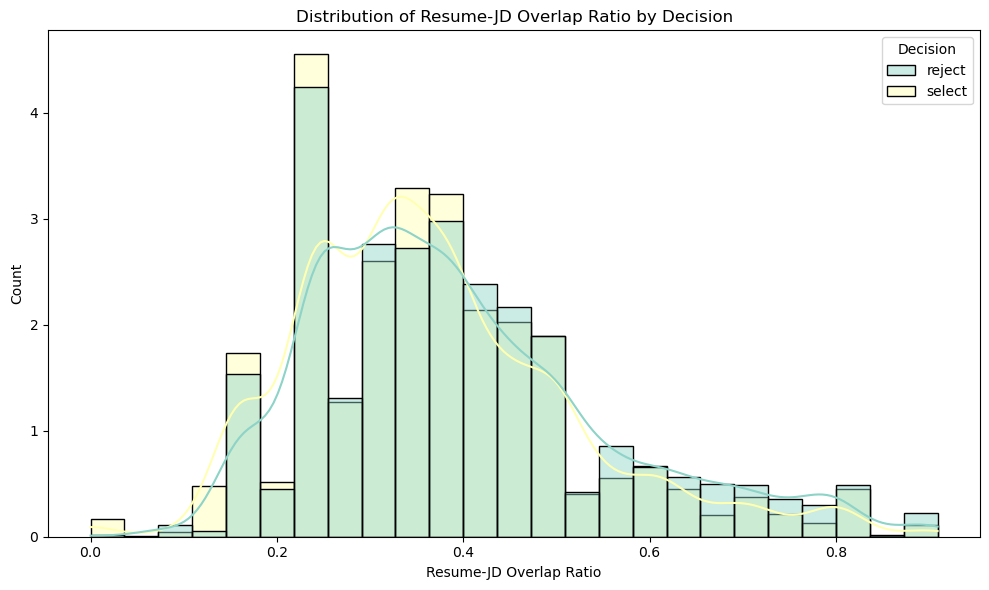

/var/folders/22/hwd4f_mj1f59f09hvlqb4m8h0000gn/T/ipykernel_79615/2896178094.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Decision', y='resume_jd_overlap_ratio', data=df, color="lightseagreen", palette='Set2', linecolor="black", linewidth=1)


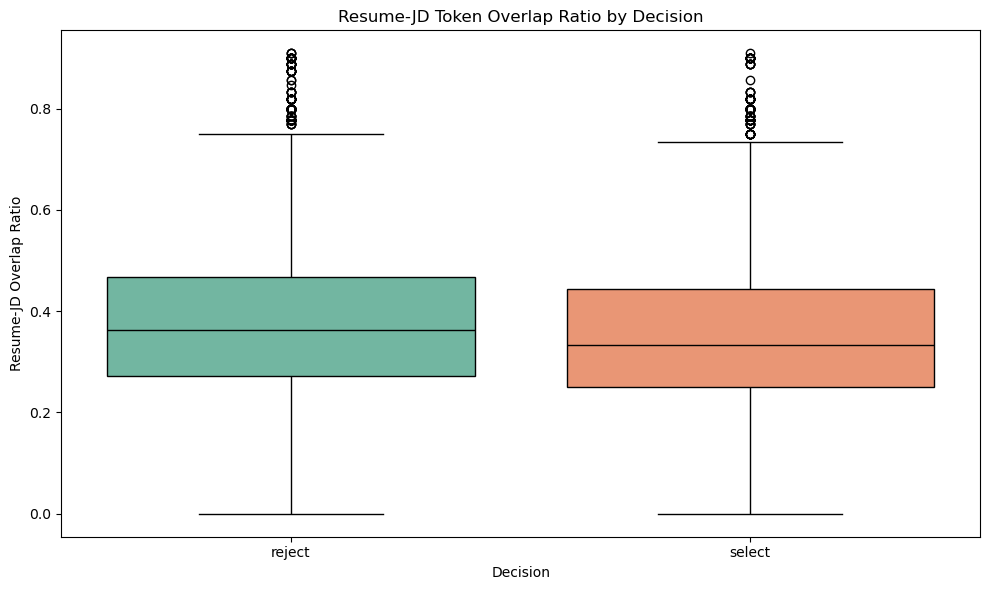

In [372]:
# Additional exploratory feature: percentage of job description tokens that overlap with resume tokens for each application, which may capture the degree of match between the resume and job description.

# This feature is calculated by taking the set intersection of the tokenized resume and job description, counting the number of overlapping tokens, and then dividing by the total number of unique tokens in the job description to get a percentage.
df['resume_jd_overlap_set_len'] = df[['Resume_tokens', 'Job_Description_tokens']].apply(lambda row: len(set(row['Resume_tokens']).intersection(set(row['Job_Description_tokens']))), axis=1)
# To avoid division by zero, we first calculate the number of unique tokens in the job description and then compute the overlap ratio only for cases where the job description has at least one token. If the job description has no tokens, we can set the overlap ratio to 0.
df['jd_tokens_set_len'] = df['Job_Description_tokens'].apply(lambda tokens: len(set(tokens)))
df['resume_jd_overlap_ratio'] = df.apply(lambda row: 0 if row['jd_tokens_set_len'] == 0 else row['resume_jd_overlap_set_len'] / row['jd_tokens_set_len'], axis=1)

# Display the first few rows of the dataset with the new overlap ratio features
print("First few rows of the dataset with resume-JD overlap ratio features:")
display(df[['Decision', 'resume_jd_overlap_set_len', 'jd_tokens_set_len', 'resume_jd_overlap_ratio']].head())

# Display statistics for the resume-JD overlap ratio by decision class to understand if there are differences in how closely resumes match job descriptions for selected vs rejected applications.
print("Resume-JD overlap ratio statistics by Decision:")
display(df.groupby('Decision')['resume_jd_overlap_ratio'].describe()) 

# visualize the distribution of the resume-JD overlap ratio for selected vs rejected applications using histograms to check the shape of the distributions
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="resume_jd_overlap_ratio", hue="Decision", bins=25, kde=True, stat="density", common_norm=False, alpha=0.45, palette="Set3", edgecolor="black", linewidth=1
)
plt.title('Distribution of Resume-JD Overlap Ratio by Decision')
plt.xlabel('Resume-JD Overlap Ratio')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Analyze the distribution of the resume-JD overlap ratio for selected vs rejected applications to compare the central tendency and spread of the overlap ratio between the two decision classes.
# To see if there are noticeable differences in how closely resumes match job descriptions for accepted vs rejected applications based on overlap ratio. This can provide insights into whether a higher overlap ratio between the resume and job description is associated with a higher likelihood of selection.
plt.figure(figsize=(10, 6))
sns.boxplot(x='Decision', y='resume_jd_overlap_ratio', data=df, color="lightseagreen", palette='Set2', linecolor="black", linewidth=1)
plt.title('Resume-JD Token Overlap Ratio by Decision')
plt.xlabel('Decision')
plt.ylabel('Resume-JD Overlap Ratio')
plt.tight_layout()
plt.show()



Output interpretation: This analysis computes a resume-JD overlap ratio for each resume-job description pair. This lexical-alignment feature measures the proportion of unique job-description tokens that also appear in the corresponding resume. For example, the first rejected sample has 3 overlapping tokens out of 12 unique job-description tokens, giving an overlap ratio of 0.25.

The summary statistics show that rejected applications have a slightly higher average overlap ratio than selected applications. The mean overlap ratio is 0.392 for rejected samples and 0.367 for selected samples, while the median is 0.364 for rejected samples and 0.333 for selected samples. Interestingly, rejected applications exhibit slightly higher lexical overlap on average than selected applications.

The histogram and boxplot show substantial overlap between the two distributions. Most samples fall between roughly 0.25 and 0.50, and both classes contain high-overlap outliers. The two distributions remain heavily overlapped despite the difference in average overlap ratios. This suggests that exact word overlap alone does not clearly distinguish selected candidates from rejected candidates.

This suggests that higher lexical overlap does not necessarily imply better hiring fit. Some rejected resumes may share many words with the job description but still lack the required experience quality, role-specific fit, or deeper relevance. Therefore, overlap ratio should be treated as an interpretable supporting feature rather than a standalone predictor.

This finding also motivates combining lexical-alignment features with semantic-alignment and explicit skill-alignment features. While overlap ratio captures explicit lexical alignment, the broader model needs additional features to capture weighted term importance, semantic similarity, and skill-specific alignment.

Potential limitation of lexical-alignment features:

Overlap ratio may favor resumes that repeat keywords directly from job descriptions, even when the candidate lacks deeper technical qualifications or relevant practical experience.

This suggests that overlap-based lexical alignment may partially capture keyword-matching behavior rather than true candidate quality.

## 9. Cosine Similarity Analysis
- Used TF-IDF `TfidfVectorizer()` to calculate the TF-IDF scores for the tokens in resumes and job descriptions for accepted vs rejected applications.

- While overlap ratio measures explicit lexical alignment between resumes and job descriptions, cosine similarity measures broader semantic alignment in TF-IDF space. This helps evaluate whether selected applications tend to have resumes that are more textually similar to the corresponding job descriptions.


First few rows of the dataset with resume-JD cosine similarity and overlap ratio feature:


,Decision,resume_jd_overlap_ratio,resume_jd_cosine_sim
0,reject,0.250000,0.197680
1,select,0.181818,0.080410
2,reject,0.428571,0.154890
3,select,0.250000,0.144820
4,reject,0.250000,0.069889


Resume-JD cosine similarity statistics by Decision:


,count,mean,std,min,25%,50%,75%,max
Decision,,,,,,,,
reject,5114.0,0.194473,0.121733,0.0,0.106043,0.170266,0.262377,0.695006
select,5060.0,0.191691,0.126337,0.0,0.101522,0.172188,0.263271,0.692349


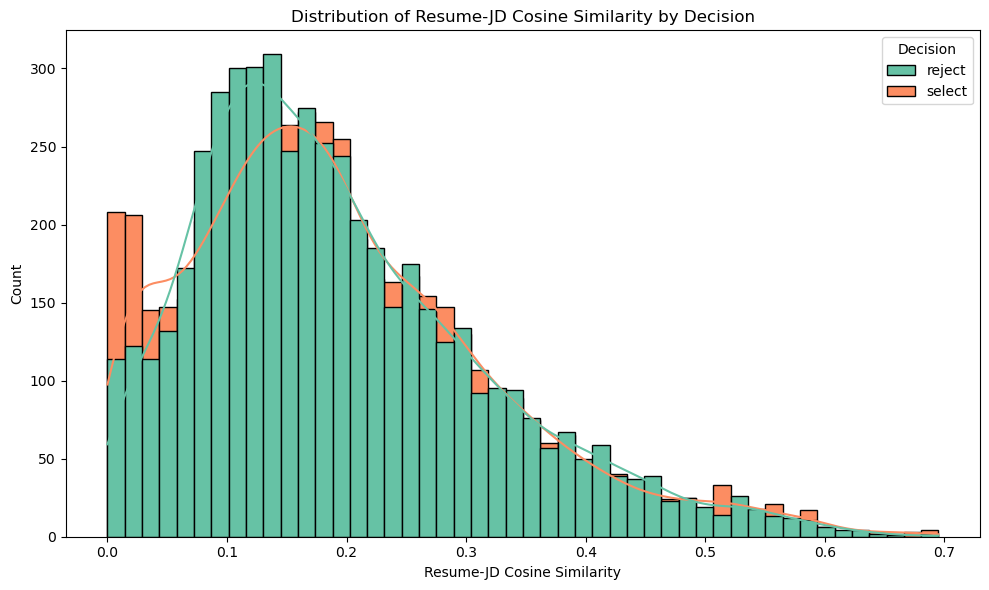

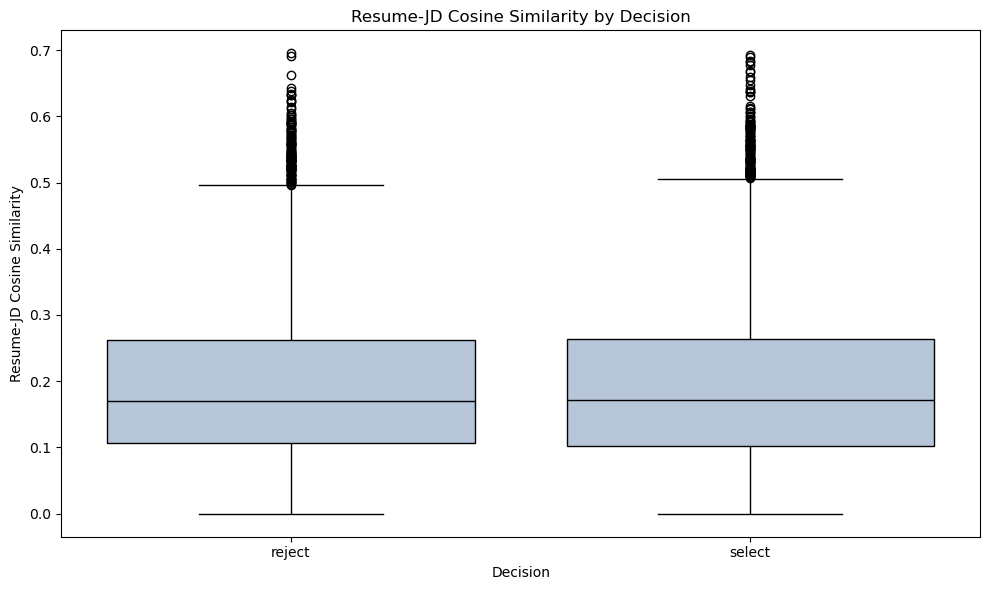

In [373]:

# Combine resume and job description text to fit a shared TF-IDF vocabulary
combined_text = pd.concat([df["Resume"], df["Job_Description"]], axis=0)

# transform all resumes and job descriptions once
resume_tfidf = tfidf_vectorizer.transform(df['Resume'])
jd_tfidf = tfidf_vectorizer.transform(df['Job_Description'])

# initialize a TfidfVectorizer with the same parameters as CountVectorizer to ensure consistency in tokenization and stop word removal, and fit it on the combined text to create a shared vocabulary and IDF values.
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z0-9]*\b',  # capture words starting with letter, followed by letters/digits; excludes pure digits and punctuation
    max_features=None  # limit to top 1000 words for clarity
)

# Fitting the TF-IDF vectorizer on the combined text of resumes and job descriptions allows us to create a unified vocabulary and calculate IDF values based on the entire corpus, which can improve the quality of the TF-IDF features when we later transform the resumes and job descriptions separately.
tfidf_vectorizer.fit(combined_text)

# calculate cosine similarity row-by-row using precomputed TF-IDF matrices
df['resume_jd_cosine_sim'] = [
    cosine_similarity(resume_tfidf[i], jd_tfidf[i])[0][0]
    for i in range(len(df))
]

# Display the first few rows of the dataset with the new cosine similarity and the overlap ratio feature
print("First few rows of the dataset with resume-JD cosine similarity and overlap ratio feature:")
display(df[['Decision', 'resume_jd_overlap_ratio', 'resume_jd_cosine_sim']].head())

# Display statistics for the resume-JD cosine similarity by decision class to understand if there are differences in how closely resumes match job descriptions for selected vs rejected applications based on cosine similarity.
print("Resume-JD cosine similarity statistics by Decision:")
display(df.groupby('Decision')['resume_jd_cosine_sim'].describe())

# Visualize the distribution of the resume-JD cosine similarity for selected vs rejected applications using histograms to check the shape of the distributions and see if there are noticeable differences in how closely resumes match job descriptions for accepted vs rejected applications based on cosine similarity.
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='resume_jd_cosine_sim', hue='Decision', kde=True, palette='Set2', alpha=1, edgecolor="black", linewidth=1)
plt.title('Distribution of Resume-JD Cosine Similarity by Decision')
plt.xlabel('Resume-JD Cosine Similarity')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Analyze the distribution of the resume-JD cosine similarity for selected vs rejected applications to compare the central tendency and spread of the cosine similarity between the two decision classes.
# To see if there are noticeable differences in how closely resumes match job descriptions for accepted vs rejected applications based on cosine similarity. This can provide insights into whether a higher cosine similarity between the resume and job description is associated with a higher likelihood of selection.
plt.figure(figsize=(10, 6))
sns.boxplot(x='Decision', y='resume_jd_cosine_sim', data=df, color="lightsteelblue", linecolor="black", linewidth=1)
plt.title('Resume-JD Cosine Similarity by Decision')
plt.xlabel('Decision')
plt.ylabel('Resume-JD Cosine Similarity')
plt.tight_layout()
plt.show()

Output interpretation: This analysis computes cosine similarity between each resume and its corresponding job description using TF-IDF vectors. Unlike overlap ratio, which measures exact shared tokens, cosine similarity measures weighted textual alignment between the two documents.

The summary statistics show that cosine similarity is nearly identical across selected and rejected applications. Rejected samples have a mean cosine similarity of 0.194, while selected samples have a mean of 0.192. The medians are also very close, with 0.170 for rejected samples and 0.172 for selected samples.

The histogram and boxplot confirm this pattern. The two distributions overlap heavily, and both classes show similar ranges and outliers. Most resume-JD pairs have relatively low to moderate cosine similarity, with values concentrated roughly between 0.10 and 0.30.

Interestingly, cosine similarity provides even weaker class separation than overlap ratio, despite capturing weighted semantic alignment through TF-IDF representations. While cosine similarity captures broader weighted text alignment than exact overlap ratio, the similarity distributions indicate that overall textual alignment is not sufficient by itself for hiring prediction. One possible reason is that many resumes and job descriptions share similar general professional vocabulary (e.g., data, development, engineering, experience, skills), causing TF-IDF similarity scores to remain relatively close across classes.

However, cosine similarity can still be useful as a supporting engineered feature. It captures a different type of alignment from overlap ratio and explicit skill-alignment features, so it may contribute useful signal when combined with other features in downstream models.


## 10. EDA Summary and Takeaways

Overall, the EDA shows that the dataset is suitable for a binary classification and ranking-based resume-job matching task. The target label is nearly balanced between `select` and `reject`, so there is no severe class imbalance issue. However, we still use Precision, Recall, and F1-score in addition to Accuracy because hiring-related prediction needs to consider both false positives and false negatives.

The length-based analyses show that resume length, job-description length, and resume/JD length ratio have only small differences between selected and rejected applications. Their distributions overlap heavily across the two decision classes. This suggests that document length alone is unlikely to strongly distinguish selected candidates from rejected candidates.

The vocabulary and word-frequency analyses show that raw BoW representations produce high-dimensional and sparse text features. Many frequent words appear in both selected and rejected samples, meaning raw word frequency alone does not clearly separate the two classes. This motivates using TF-IDF instead of relying only on raw BoW counts, since TF-IDF downweights overly common terms and emphasizes more informative words.

The technical skill analysis shows that explicit skill matching provides an interpretable signal, but the differences between selected and rejected applications are relatively small. Skills such as `java`, `aws`, `azure`, `python`, and `docker` have slightly higher resume–JD match rates among selected applications, but the largest difference is still below 1 percentage point. Therefore, individual skill matches should be treated as supporting features rather than standalone predictors.

The lexical-alignment analysis based on overlap ratio shows that exact lexical overlap between resumes and job descriptions does not clearly separate selected and rejected applications. Rejected applications even have a slightly higher average overlap ratio than selected applications. This suggests that sharing many words with a job description does not necessarily imply stronger hiring fit.

The semantic-alignment analysis based on TF-IDF cosine similarity shows a similar pattern. Resume–JD cosine similarity scores are nearly identical across selected and rejected applications, and the distributions overlap heavily. This suggests that TF-IDF-based semantic alignment alone may not be sufficient as a standalone predictor for hiring decisions in this dataset.

Taken together, these findings suggest that no single surface-level feature is enough to solve the resume-job matching task. Different engineered features capture different aspects of resume-job matching. Lexical-alignment features capture explicit keyword overlap, semantic-alignment features capture broader weighted textual similarity, and explicit skill-alignment features capture technology-specific matching signals.

Therefore, the downstream model should combine multiple complementary signals, including:

- TF-IDF text representations
- overlap ratio
- cosine similarity
- explicit skill-alignment features
- interpretable classifiers such as Logistic Regression
- nonlinear comparison models such as Random Forest or XGBoost

The EDA supports the project’s main methodology: using classic machine learning with engineered resume-job alignment features, then evaluating both classification quality and ranking quality. The results also motivate downstream error analysis and feature-importance analysis, because some rejected applications still exhibit high lexical or semantic alignment scores. This suggests that model behavior should be interpreted carefully rather than relying only on aggregate metrics.